<a href="https://colab.research.google.com/github/starsyntaxx/nigeria-car-price-prediction/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import zipfile

zip_path = '/content/drive/MyDrive/ML PROJECTS/nigeria-car-price-prediction/data/raw/nigeria_car_data.zip'

extract_path = 'data/raw/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [3]:
import os

os.listdir(extract_path)

['vroomvroom.csv']

In [4]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML PROJECTS/nigeria-car-price-prediction/data/raw/vroomvroom.csv')

df.head()

,Unnamed: 0,Make,Model,Year of Manufacture,Color,Price,Location,Trim,Drivetrain,Engine Size,Number of Cylinders,Horse Power,Interior Color,Seats,Registered Car,Second Condition,Body,Exchange Possible,VIN Chassis number
0,0,Mercedes-Benz,C180,2000,Blue,4000000.0,Kano,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Mercedes-Benz,E350,2014,Black,13500000.0,Abuja,Base 4Matic Sedan AWD (3.5L 6cyl 7A),All Wheel,3500cc,6.0,302hp,Brown,5,Yes,NaN,NaN,NaN,NaN
2,2,Toyota,Sienna,2012,Black,16999999.0,Lagos,SE 8 Passenger,Front Wheel,3500cc,6.0,270hp,Black,8,No,No faults,Minivan,No,NaN
3,3,Mercedes-Benz,GLE-Class,2021,Blue,190000000.0,Lagos,AMG GLE 53 4MATIC,All Wheel,3000cc,6.0,429hp,Other,5,No,No faults,SUV,NaN,NaN
4,4,Honda,Accord,2005,Silver,2800000.0,Kaduna,2.4 Type S Automatic,Front Wheel,NaN,NaN,NaN,Black,NaN,Yes,"First owner, First registration, No faults",NaN,NaN,NaN


In [5]:
df = pd.read_csv("data/raw/vroomvroom.csv")
df = df.drop(columns=["Unnamed: 0"])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1217 entries, 0 to 1216
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Make                 1217 non-null   object 
 1   Model                1217 non-null   object 
 2   Year of Manufacture  1217 non-null   int64  
 3   Color                1217 non-null   object 
 4   Price                1217 non-null   float64
 5   Location             1217 non-null   object 
 6   Trim                 824 non-null    object 
 7   Drivetrain           704 non-null    object 
 8   Engine Size          705 non-null    object 
 9   Number of Cylinders  763 non-null    float64
 10  Horse Power          659 non-null    object 
 11  Interior Color       1020 non-null   object 
 12  Seats                695 non-null    object 
 13  Registered Car       1000 non-null   object 
 14  Second Condition     1027 non-null   object 
 15  Body                 730 non-null    o

In [7]:
df.describe()

,Year of Manufacture,Price,Number of Cylinders
count,1217.000000,1.217000e+03,763.000000
mean,2013.914544,3.287482e+07,5.941022
std,4.054026,3.521778e+07,1.119117
min,1971.000000,2.600000e+06,3.000000
25%,2012.000000,1.655000e+07,6.000000
50%,2014.000000,2.630000e+07,6.000000
75%,2016.000000,3.900000e+07,6.000000
max,2024.000000,5.120000e+08,12.000000


In [8]:
df.isnull().sum()

,0
Make,0
Model,0
Year of Manufacture,0
Color,0
Price,0
Location,0
Trim,393
Drivetrain,513
Engine Size,512
Number of Cylinders,454


**Split the data**:
Understanding data to apply needed splitting strategy

Since locations like `Rivers`, `Ogun`, `Ondo`, and `Imo` only have 1 or 2 occurrences, we group them into a broader `'Other'` category before performing splits or training. This ensures consistent feature categories across train and test sets.

In [9]:
# Identify rare locations (e.g., threshold of 5 listings)
threshold = 5
location_counts = df['Location'].value_counts()
rare_locations = location_counts[location_counts < threshold].index

# Create a cleaned Location column on the original dataframe
df['Location_clean'] = df['Location'].replace(rare_locations, 'Other')

print("Original Locations count:", df['Location'].nunique())
print("Cleaned Locations count:", df['Location_clean'].nunique())
print("New distribution:")
display(df['Location_clean'].value_counts())

Original Locations count: 13
Cleaned Locations count: 5
New distribution:


,count
Location_clean,
Lagos,1071
Abuja,107
Other,17
Kano,14
Enugu,8


In [10]:
 df= df.drop(columns=['Location'])

#### **Stratified Split or Category-Grouped Split**
Since `Price` (your target variable) is highly dependent on `Make` (e.g., Mercedes-Benz vs. Toyota) and `Year of Manufacture`, a standard random split might cause a mismatch in distribution between your training and validation/test sets.

1. **Stratification on Year/Price bins:** Bin the `Price` or `Year of Manufacture` into categories and use `train_test_split(..., stratify=bins)` to ensure that both training and testing datasets represent expensive/cheap and old/new cars in equal proportions.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

df['Price_cat'] = pd.cut(
    df["Price"],
    bins=np.linspace(
        df["Price"].min(),
        df["Price"].max(),
        5
    ),
    include_lowest=True
)

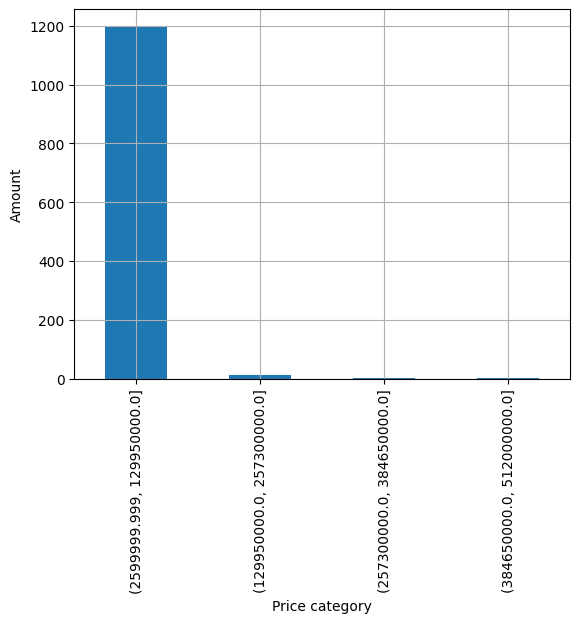

In [12]:
df["Price_cat"].value_counts().sort_index().plot.bar(rot=90, grid=True)
plt.xlabel("Price category")
plt.ylabel("Amount")
plt.show()

In [13]:
df[df['Price_cat'].isna()]

,Make,Model,Year of Manufacture,Color,Price,Trim,Drivetrain,Engine Size,Number of Cylinders,Horse Power,Interior Color,Seats,Registered Car,Second Condition,Body,Exchange Possible,VIN Chassis number,Location_clean,Price_cat


In [14]:
# from sklearn.model_selection import StratifiedShuffleSplit

# splitter = StratifiedShuffleSplit(
#     n_splits=10,
#     test_size = 0.2,
#     random_state=42
# )

# strat_splits = []

# for train_index, test_index in splitter.split(
#     df,
#     df['Price_cat']):
#     strat_train_set_n = df.iloc[train_index]
#     strat_test_set_n = df.iloc[test_index]

#     strat_splits.append([strat_train_set_n, strat_test_set_n])

In [15]:
# strat_train_set, strat_test_set = strat_splits[0]

In [16]:
# a simplified version of stratified splitting
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Price_cat"],
    random_state=42
)

In [17]:
strat_train_set.shape

(973, 19)

In [18]:
strat_test_set.shape

(244, 19)

In [19]:
df['Price_cat'].dtype

CategoricalDtype(categories=[(2599999.999, 129950000.0], (129950000.0, 257300000.0],
                  (257300000.0, 384650000.0], (384650000.0, 512000000.0]],
, ordered=True, categories_dtype=interval[float64, right])

In [20]:

def price_cat_proportions(data):
    return data["Price_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": price_cat_proportions(df),
    "Stratified %": price_cat_proportions(strat_test_set),
    "Random %": price_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
"(2599999.999, 129950000.0]",98.27,98.36,98.36,0.09,0.09
"(129950000.0, 257300000.0]",1.07,0.82,1.23,-23.27,15.10
"(257300000.0, 384650000.0]",0.33,0.41,0.00,24.69,-100.00
"(384650000.0, 512000000.0]",0.33,0.41,0.41,24.69,24.69


In [21]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("Price_cat", axis=1, inplace=True)

**Discover and Visualize the Data to Gain Insights**

In [22]:
car = strat_train_set.copy()

In [28]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 973 entries, 812 to 718
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Make                 973 non-null    object 
 1   Model                973 non-null    object 
 2   Year of Manufacture  973 non-null    int64  
 3   Color                973 non-null    object 
 4   Price                973 non-null    float64
 5   Trim                 663 non-null    object 
 6   Drivetrain           563 non-null    object 
 7   Engine Size          568 non-null    object 
 8   Number of Cylinders  612 non-null    float64
 9   Horse Power          531 non-null    object 
 10  Interior Color       826 non-null    object 
 11  Seats                554 non-null    object 
 12  Registered Car       797 non-null    object 
 13  Second Condition     817 non-null    object 
 14  Body                 585 non-null    object 
 15  Exchange Possible    309 non-null    object

In [27]:
car.describe()

,Year of Manufacture,Price,Number of Cylinders
count,973.000000,9.730000e+02,612.000000
mean,2013.944502,3.311688e+07,5.926471
std,3.931382,3.516372e+07,1.110647
min,2000.000000,2.600000e+06,3.000000
25%,2012.000000,1.680000e+07,6.000000
50%,2014.000000,2.630000e+07,6.000000
75%,2016.000000,3.850000e+07,6.000000
max,2024.000000,5.120000e+08,12.000000


In [32]:
car.isnull().sum()

,0
Make,0
Model,0
Year of Manufacture,0
Color,0
Price,0
Trim,310
Drivetrain,410
Engine Size,405
Number of Cylinders,361
Horse Power,442


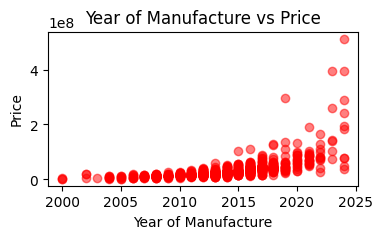

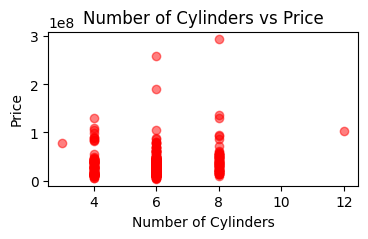

In [41]:
import matplotlib.pyplot as plt

# Loop through columns and plot numerical features against Price
for col in car.columns:
    if col != 'Price' and car[col].dtype in ['int64', 'float64']:
        plt.figure(figsize=(4, 2))
        plt.scatter(x=car[col], y=car['Price'], alpha=0.5, color='red')
        plt.xlabel(col)
        plt.ylabel('Price')
        plt.title(f'{col} vs Price')
        plt.show()

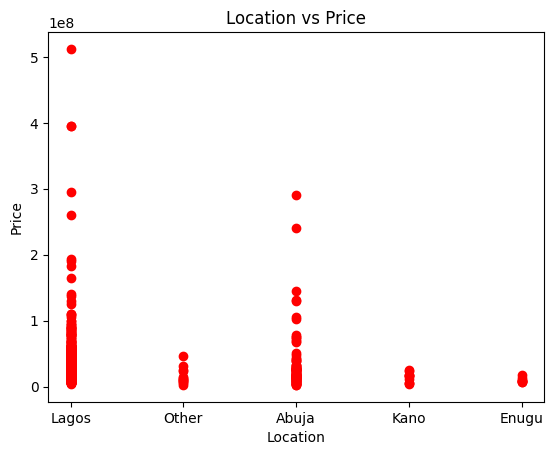

In [23]:

plt.scatter(car['Location_clean'], car['Price'], color='red')
plt.xlabel('Location')
plt.ylabel('Price')
plt.title('Location vs Price')
plt.show()

In [44]:
car['Make'].dtype

dtype('O')

In [24]:
df['Make'].value_counts()

,count
Make,
Lexus,409
Mercedes-Benz,380
Toyota,331
Hyundai,23
Land Rover,19
Honda,17
Acura,6
Ford,5
Nissan,4


In [25]:
df['Model'].value_counts()

,count
Model,
RX,132
Highlander,128
GLK-Class,115
ES,96
GX,89
...,...
Panamera,1
XJ,1
C-Class,1


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

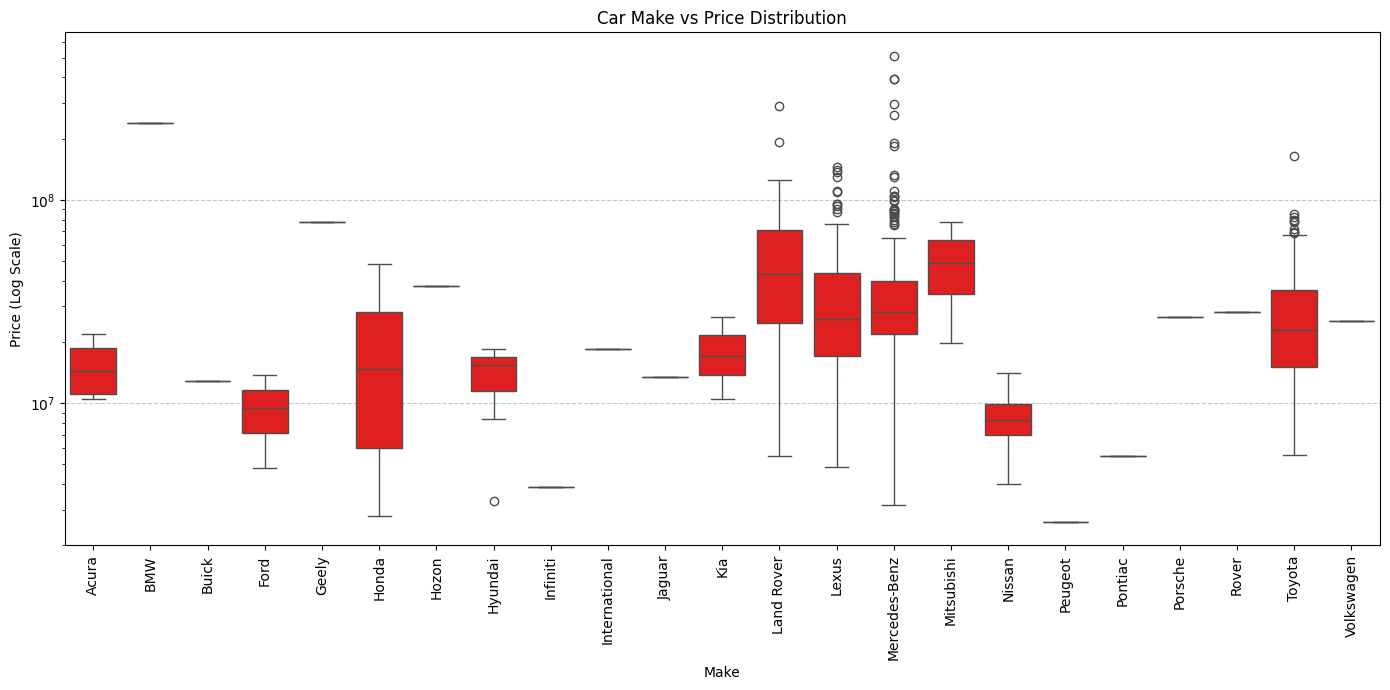

In [53]:
# Convert 'Make' column to categorical in both dfs
car['Make'] = car['Make'].astype('category')

# Visualize 'Make' vs 'Price' using a boxplot to handle category distributions
plt.figure(figsize=(14, 7))
sns.boxplot(data=car, x='Make', y='Price', color='red')
plt.xticks(rotation=90)
plt.title('Car Make vs Price Distribution')
plt.yscale('log')  # Using log scale due to high price variance and outliers
plt.ylabel('Price (Log Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Exploring the Relationship between Make and Model
Since `Model` is nested within `Make` (each model is produced by a specific brand), we can analyze this hierarchical relationship by looking at the distribution of models within the top three most frequent makes (`Lexus`, `Mercedes-Benz`, and `Toyota`).

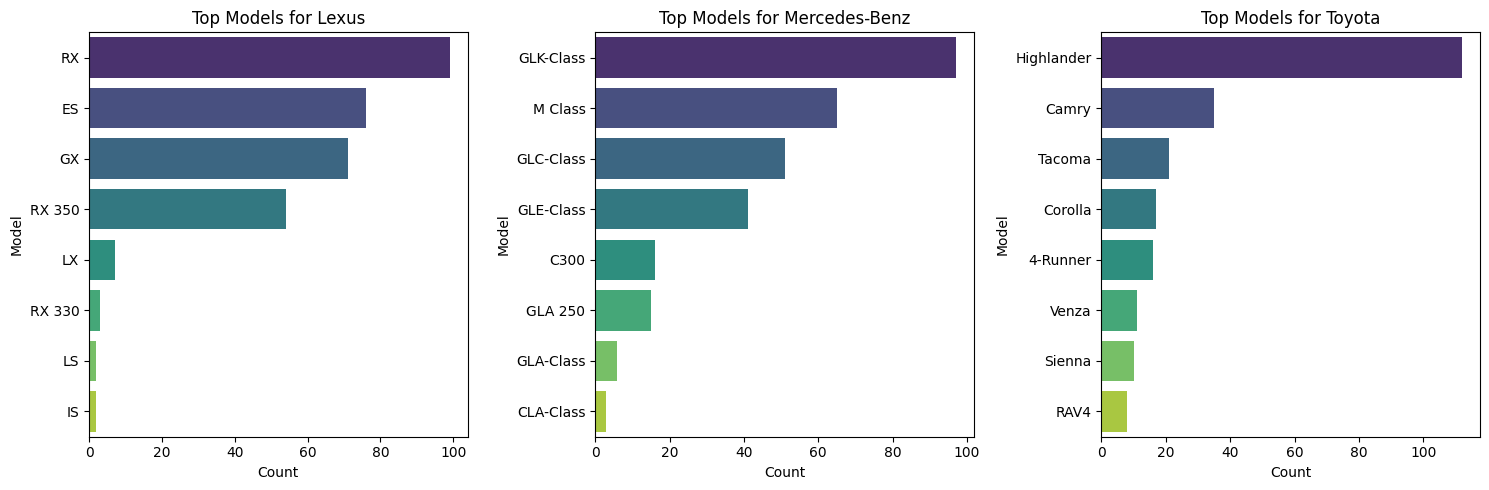

In [54]:
# Get the top 3 makes in the dataset
top_makes = car['Make'].value_counts().head(3).index.tolist()

# For each of the top makes, let's find their top 8 most common models
plt.figure(figsize=(15, 5))

for i, make in enumerate(top_makes, 1):
    plt.subplot(1, 3, i)
    make_data = car[car['Make'] == make]
    top_models = make_data['Model'].value_counts().head(8)

    # Assigning y as hue and setting legend=False to prevent FutureWarnings
    sns.barplot(x=top_models.values, y=top_models.index, hue=top_models.index, palette='viridis', legend=False)
    plt.title(f'Top Models for {make}')
    plt.xlabel('Count')
    plt.ylabel('Model')

plt.tight_layout()
plt.show()

### 1. What Could Go Wrong During Model Training?
* **High Percentage of Missing Values:**
  * `VIN Chassis number` is missing in almost 99% of rows (1207 nulls out of 1217). This column should be dropped entirely.
  * `Exchange Possible` has 839 missing values. This can be treated as a separate category (e.g., 'Unknown') or filled with 'No'.
  * Key technical specifications like `Drivetrain` (513 nulls), `Engine Size` (512 nulls), `Number of Cylinders` (454 nulls), and `Horse Power` (558 nulls) have high rates of missingness. Simply dropping these rows would discard nearly half of your dataset. You should look into smart imputation (e.g., imputing missing technical specs based on the median/mode of the same `Make` and `Model`).

* **Extremely Imbalanced Categorical Features**

* **Data Type Mismatches:**
  * `Engine Size` (e.g., '3500cc') and `Horse Power` (e.g., '302hp') are currently stored as `object` (text) types because of their units. These must be cleaned to extract numerical values (e.g., converting '3500cc' to `3500.0`) so the model can utilize them numerically.
  * `Seats` is also an `object` type and should be converted to numeric.

---



### 3. Addressing the "Lagos Price Cap" Bias

Your observation is spot on: **Only cars in Lagos reach extreme price points (outliers)**. This occurs because the distribution of luxury versus economy vehicles is heavily skewed by region (Lagos is the economic hub with more ultra-high-end vehicles like the 190M Naira GLE-Class shown in `df.head()`).

If you train a simple regression model on this, it may learn that `Location == 'Lagos'` is the primary driver for high prices rather than the actual car specs, leading to:
* **Artificial price capping** for luxury cars listed in other cities (e.g., Abuja).
* **Overpredicting** the value of low-end or economy cars just because they are located in Lagos.

#### **How to prevent this in model training:**

1. **Use Target Transformation (Log Transform):**
   * Price is highly skewed. Applying a logarithmic transformation (`y_train = np.log1p(df['Price'])`) compresses the range of extreme outliers, preventing Lagos luxury cars from dominating the loss function during model training.

2. **Feature Interaction Terms:**
   * Ensure the model doesn't treat `Location` and technical specs completely independently. Algorithms like Decision Trees, Random Forests, or Gradient Boosted Trees (XGBoost/LightGBM) naturally capture interactions (e.g., `Location == 'Lagos'` + `Model == 'GLE-Class'`). For linear models, you would need to manually create interaction features.

3. **Model without Location First:**
   * A robust strategy is to train a baseline model using **only** physical car attributes (`Make`, `Model`, `Year`, `Engine Size`, `Horse Power`) to establish the "intrinsic" value of the car first. Afterward, you can add `Location` as a secondary modifier feature to capture regional market premiums.